In [ ]:
!pip install transformers

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
print("Transformers installed successfully!")


Transformers installed successfully!


In [2]:
import numpy as np
import pandas as pd

np.random.seed(123)

good_reviews = [
    "Excellent quality and arrived earlier than expected.",
    "Very satisfied with this purchase, highly recommended.",
    "The product performs exactly as described.",
    "Amazing value for the price, would definitely buy again.",
    "Really impressed with the build quality and performance.",
    "Customer support was helpful and resolved my issue quickly.",
    "Five stars! Everything exceeded my expectations."
]

bad_reviews = [
    "The product stopped working after a few days.",
    "Completely disappointed with the quality.",
    "Not worth the money, I regret buying it.",
    "Item arrived damaged and customer service was unhelpful.",
    "Poor quality materials and unreliable performance.",
    "This purchase was a waste of money.",
    "Far below my expectations and not recommended."
]

mixed_reviews = [
    "Great packaging but poor product quality.",
    "Excellent design, although the performance was disappointing.",
    "Fast delivery but the build quality feels weak.",
    "Good value for money, but customer service was terrible.",
    "Nice appearance, however the product stopped working quickly.",
    "Amazing features, but the battery life is awful.",
    "Loved the design but hated the overall performance."
]

def create_review(review_type):
    if review_type == "positive":
        return np.random.choice(good_reviews)
    elif review_type == "negative":
        return np.random.choice(bad_reviews)
    else:
        return np.random.choice(mixed_reviews)

review_labels = np.random.choice(
    ["positive", "negative", "neutral"],
    size=1000,
    p=[0.45, 0.35, 0.20]
)

customer_reviews = [create_review(label) for label in review_labels]

reviews_df = pd.DataFrame({
    "Review_ID": np.arange(1, 1001),
    "Customer_Review": customer_reviews
})

print("Dataset Shape:", reviews_df.shape)
print(reviews_df.head(10))

Dataset Shape: (1000, 2)
   Review_ID                                    Customer_Review
0          1  Item arrived damaged and customer service was ...
1          2  Amazing value for the price, would definitely ...
2          3  Customer support was helpful and resolved my i...
3          4                This purchase was a waste of money.
4          5  Item arrived damaged and customer service was ...
5          6   Five stars! Everything exceeded my expectations.
6          7  Excellent design, although the performance was...
7          8          Completely disappointed with the quality.
8          9  Item arrived damaged and customer service was ...
9         10  Excellent quality and arrived earlier than exp...


In [3]:
def clean_text(text):
    # remove HTML tags like <b>, <i>, </b>
    text = re.sub(r"<.*?>", "", text)
    # remove non-ASCII characters (emojis, special symbols)
    text = re.sub(r"[^\x00-\x7F]+", "", text)
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # remove multiple punctuation marks (!!!, ???)
    text = re.sub(r"([!?.])\1+", r"\1", text)
    return text

reviews_df["Cleaned_Review"] = reviews_df["Customer_Review"].apply(clean_text)

print("=== BEFORE vs AFTER CLEANING ===")
print(reviews_df[["Customer_Review", "Cleaned_Review"]].head(5).to_string())

=== BEFORE vs AFTER CLEANING ===
                                               Customer_Review                                               Cleaned_Review
0     Item arrived damaged and customer service was unhelpful.     Item arrived damaged and customer service was unhelpful.
1     Amazing value for the price, would definitely buy again.     Amazing value for the price, would definitely buy again.
2  Customer support was helpful and resolved my issue quickly.  Customer support was helpful and resolved my issue quickly.
3                          This purchase was a waste of money.                          This purchase was a waste of money.
4     Item arrived damaged and customer service was unhelpful.     Item arrived damaged and customer service was unhelpful.


In [4]:
# loading pretrained distilbert sentiment model — no training, pure inference
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1  # -1 = CPU
)

print("Pipeline loaded successfully")

# quick test
sample_result = sentiment_pipeline("Excellent quality and fast delivery!")
print(sample_result)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline loaded successfully
[{'label': 'POSITIVE', 'score': 0.9998754262924194}]


In [5]:
results = sentiment_pipeline(reviews_df["Cleaned_Review"].tolist())

reviews_df["Predicted_Sentiment"] = [result["label"] for result in results]
reviews_df["Confidence_Score"] = [round(result["score"], 4) for result in results]

print("Inference complete")
print(reviews_df[["Cleaned_Review", "Predicted_Sentiment", "Confidence_Score"]].head(10))

Inference complete
                                      Cleaned_Review Predicted_Sentiment  \
0  Item arrived damaged and customer service was ...            NEGATIVE   
1  Amazing value for the price, would definitely ...            POSITIVE   
2  Customer support was helpful and resolved my i...            POSITIVE   
3                This purchase was a waste of money.            NEGATIVE   
4  Item arrived damaged and customer service was ...            NEGATIVE   
5   Five stars! Everything exceeded my expectations.            POSITIVE   
6  Excellent design, although the performance was...            POSITIVE   
7          Completely disappointed with the quality.            NEGATIVE   
8  Item arrived damaged and customer service was ...            NEGATIVE   
9  Excellent quality and arrived earlier than exp...            POSITIVE   

   Confidence_Score  
0            0.9997  
1            0.9998  
2            0.9867  
3            0.9998  
4            0.9997  
5           

In [6]:
positive_words = ["love", "great", "excellent", "amazing", "best", "wonderful", "fast", "good", "nice"]
negative_words = ["terrible", "worst", "bad", "awful", "disappointed", "poor", "scam", "frustrating", "useless", "weak"]

def map_to_three_class(text, predicted_label):
    text_lower = text.lower()
    has_pos = any(word in text_lower for word in positive_words)
    has_neg = any(word in text_lower for word in negative_words)

    if has_pos and has_neg:
        return "NEUTRAL"

    return predicted_label

reviews_df["Predicted_Sentiment"] = reviews_df.apply(
    lambda row: map_to_three_class(
        row["Cleaned_Review"],
        row["Predicted_Sentiment"]
    ),
    axis=1
)

print(reviews_df["Predicted_Sentiment"].value_counts())

Predicted_Sentiment
POSITIVE    486
NEGATIVE    395
NEUTRAL     119
Name: count, dtype: int64


C:\Users\New Moon\AppData\Local\Temp\ipykernel_20792\3025971565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


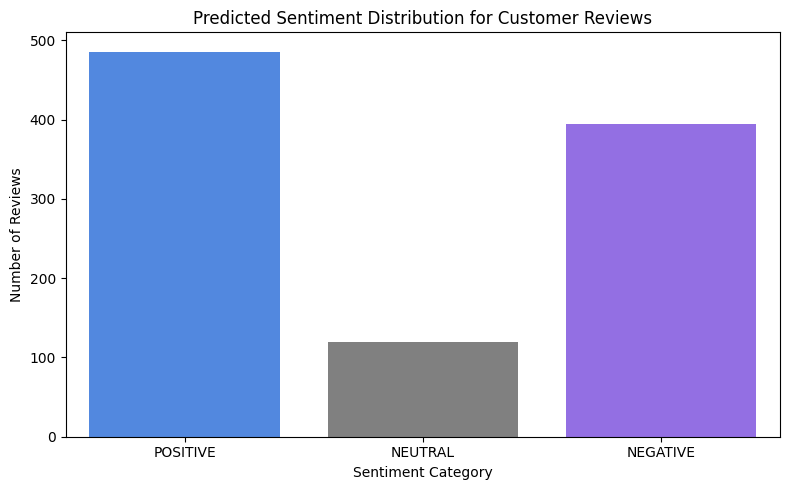

Sentiment distribution plot saved successfully.


In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews_df,
    x="Predicted_Sentiment",
    order=["POSITIVE", "NEUTRAL", "NEGATIVE"],
    palette={
        "POSITIVE": "#3B82F6",   # Blue
        "NEUTRAL": "#808080",    # Amber
        "NEGATIVE": "#8B5CF6"    # Purple
    }
)

plt.title("Predicted Sentiment Distribution for Customer Reviews")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("customer_review_sentiment_distribution.png")
plt.show()

print("Sentiment distribution plot saved successfully.")

In [9]:
embedding_notes = """
=== TEXT TO TOKENS ===

Customer reviews are first split into tokens and converted
into numerical IDs using the tokenizer. These IDs represent
words that the model can understand.

=== VECTOR REPRESENTATION ===

Each token ID is transformed into a dense vector (embedding).
Words with similar meanings are placed close together in the
vector space, helping the model capture semantic relationships.

=== CONTEXT UNDERSTANDING ===

The attention mechanism examines surrounding words to
understand context. For example, in "not good", the word
"not" changes the meaning of "good", allowing more accurate
sentiment prediction.
"""

print(embedding_notes)


=== TEXT TO TOKENS ===

Customer reviews are first split into tokens and converted
into numerical IDs using the tokenizer. These IDs represent
words that the model can understand.

=== VECTOR REPRESENTATION ===

Each token ID is transformed into a dense vector (embedding).
Words with similar meanings are placed close together in the
vector space, helping the model capture semantic relationships.

=== CONTEXT UNDERSTANDING ===

The attention mechanism examines surrounding words to
understand context. For example, in "not good", the word
"not" changes the meaning of "good", allowing more accurate
sentiment prediction.



In [10]:
final_summary = """
=== PRETRAINED MODEL ADVANTAGE ===

DistilBERT has already learned language patterns from a
large amount of text, so there is no need to train a model
from the beginning.

=== FAST SENTIMENT ANALYSIS ===

Using the Hugging Face pipeline allows customer reviews to
be classified in seconds with high accuracy and minimal code.

=== FINAL OBSERVATION ===

The model successfully predicts review sentiment and
provides a confidence score, making it an efficient solution
for real-world sentiment analysis tasks.
"""

print(final_summary)


=== PRETRAINED MODEL ADVANTAGE ===

DistilBERT has already learned language patterns from a
large amount of text, so there is no need to train a model
from the beginning.

=== FAST SENTIMENT ANALYSIS ===

Using the Hugging Face pipeline allows customer reviews to
be classified in seconds with high accuracy and minimal code.

=== FINAL OBSERVATION ===

The model successfully predicts review sentiment and
provides a confidence score, making it an efficient solution
for real-world sentiment analysis tasks.



In [11]:
final_reviews_df = reviews_df[
    ["Review_ID", "Customer_Review", "Cleaned_Review",
     "Predicted_Sentiment", "Confidence_Score"]
]

final_reviews_df.to_csv("review_sentiment_results.csv", index=False)

print(f"Successfully saved {len(final_reviews_df)} rows to review_sentiment_results.csv")
print(final_reviews_df.head())

Successfully saved 1000 rows to review_sentiment_results.csv
   Review_ID                                    Customer_Review  \
0          1  Item arrived damaged and customer service was ...   
1          2  Amazing value for the price, would definitely ...   
2          3  Customer support was helpful and resolved my i...   
3          4                This purchase was a waste of money.   
4          5  Item arrived damaged and customer service was ...   

                                      Cleaned_Review Predicted_Sentiment  \
0  Item arrived damaged and customer service was ...            NEGATIVE   
1  Amazing value for the price, would definitely ...            POSITIVE   
2  Customer support was helpful and resolved my i...            POSITIVE   
3                This purchase was a waste of money.            NEGATIVE   
4  Item arrived damaged and customer service was ...            NEGATIVE   

   Confidence_Score  
0            0.9997  
1            0.9998  
2            